# 05 — LSS Training Analysis (Phase 5)

What this covers:
1. Verify training components (loss, optimizer, augmentation)
2. LR schedule visualisation — CosineAnnealingLR decay curve
3. BEV loss on one real batch before training
4. Post-training: load checkpoint, inspect val mIoU
5. Depth distribution evolution — untrained vs trained comparison
6. BEV prediction visualisation — trained model output on val sample

In [3]:
import sys
from pathlib import Path

# Get the current working directory of the notebook
current_dir = Path.cwd()

# Check if 'src' exists in the current directory (meaning CWD is already the project root)
if (current_dir / 'src').exists():
    PROJECT_ROOT = current_dir
# Otherwise, assume CWD is the 'notebooks' folder and go up one level
else:
    PROJECT_ROOT = current_dir.parent

# Resolve the absolute path to the src directory
src_path = str(PROJECT_ROOT / 'src')

# Add it to sys.path (checking first to avoid adding it multiple times if you re-run the cell)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import torch
import matplotlib.pyplot as plt

from utils.config import TRAIN, CLASSES, BEV, SEGFORMER, PATHS
from utils.device import get_device

device = get_device(verbose=True)
print('Ready')

[device] Using: mps
[device] Apple MPS backend active - M3 GPU will be used.
Ready


## 1. Verify training components

In [4]:
from train.losses       import bev_loss, BEVIoUMetric
from train.augmentations import augment_lss
from train.optimizers   import build_lss_optimizer
from train.checkpointing import lss_path
from models.lss.lss_model import LSSModel

# quick smoke test
B, C = 2, CLASSES['num_classes']
logits = torch.randn(B, C, BEV['size'], BEV['size'])
gt     = torch.zeros(B, C, BEV['size'], BEV['size'])
loss   = bev_loss(logits, gt, TRAIN['lss']['pos_weights'])
print(f'bev_loss: {loss.item():.4f}  (finite={torch.isfinite(loss).item()})')

img = torch.rand(3, SEGFORMER['img_h'], SEGFORMER['img_w'])
bev = torch.zeros(C, BEV['size'], BEV['size'])
img2, bev2 = augment_lss(img, bev)
print(f'augment_lss: image {tuple(img2.shape)}  bev_gt {tuple(bev2.shape)}')
print(f'Checkpoint path: {lss_path()}')
print(f'Checkpoint exists: {lss_path().exists()}')

bev_loss: 0.8074  (finite=True)
augment_lss: image (3, 512, 1024)  bev_gt (3, 200, 200)
Checkpoint path: /Users/akshar/Desktop/bev-semantic-map/checkpoints/lss_best.pth
Checkpoint exists: True


## 2. LR schedule visualisation

/Users/akshar/miniconda3/envs/bev/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


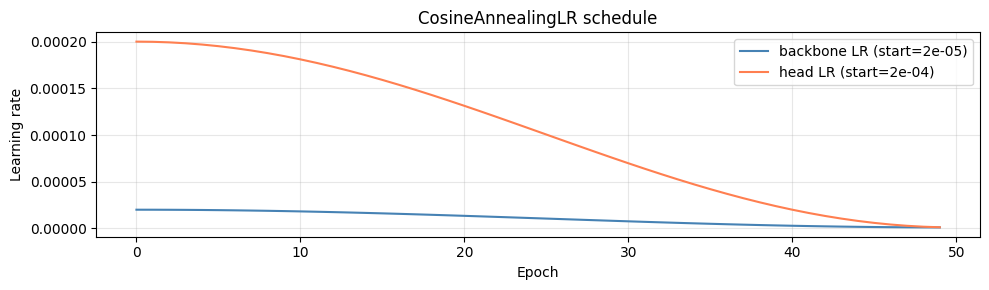

Backbone LR: 2.00e-05 → 1.02e-06
Head LR:     2.00e-04 → 1.20e-06


In [5]:
# simulate CosineAnnealingLR across all epochs
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from models.lss.lss_model import LSSModel

cfg  = TRAIN['lss']
_m   = LSSModel()
_opt = optim.AdamW([
    {'params': _m.lift.backbone.parameters(), 'lr': cfg['backbone_lr']},
    {'params': _m.shoot.parameters(),         'lr': cfg['head_lr']},
])
_sch = CosineAnnealingLR(_opt, T_max=cfg['epochs'], eta_min=cfg['eta_min'])

backbone_lrs, head_lrs = [], []
for _ in range(cfg['epochs']):
    backbone_lrs.append(_opt.param_groups[0]['lr'])
    head_lrs.append(_opt.param_groups[1]['lr'])
    _sch.step()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(backbone_lrs, label=f'backbone LR (start={cfg["backbone_lr"]:.0e})', color='steelblue')
ax.plot(head_lrs,     label=f'head LR (start={cfg["head_lr"]:.0e})',     color='coral')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate')
ax.set_title('CosineAnnealingLR schedule')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Backbone LR: {backbone_lrs[0]:.2e} → {backbone_lrs[-1]:.2e}')
print(f'Head LR:     {head_lrs[0]:.2e} → {head_lrs[-1]:.2e}')

## 3. BEV loss on one real batch

In [6]:
from data.nuscenes_dataset import build_dataloader
from models.lss.lss_model import LSSModel
from train.losses import bev_loss

val_loader = build_dataloader('val', batch_size=1, shuffle=False)
batch      = next(iter(val_loader))

print('Batch keys:', list(batch.keys()))
print(f'image:   {tuple(batch["image"].shape)}')
print(f'K:       {tuple(batch["K"].shape)}')
print(f'bev_gt:  {tuple(batch["bev_gt"].shape)}')
print(f'location: {batch["location"]}')

# untrained model loss
model_fresh = LSSModel().to(device).eval()
imgs = batch['image'].to(device)
K    = batch['K'].to(device)
T    = batch['T_cam2ego'].to(device)
gt   = batch['bev_gt'].to(device)

with torch.no_grad():
    logits, _ = model_fresh(imgs, K, T)

loss_untrained = bev_loss(logits, gt, TRAIN['lss']['pos_weights'])
print(f'\nUntrained model BEV loss: {loss_untrained.item():.4f}')
print(f'Logits range: [{logits.min().item():.3f}, {logits.max().item():.3f}]')

for i, name in enumerate(CLASSES['names']):
    gt_pos = batch['bev_gt'][0, i].sum().item()
    print(f'  GT {name}: {int(gt_pos)} positive pixels')

[Dataset] split=val  samples=80
Batch keys: ['image', 'K', 'T_cam2ego', 'T_ego2world', 'bev_gt', 'sample_token', 'location']
image:   (1, 3, 512, 1024)
K:       (1, 3, 3)
bev_gt:  (1, 3, 200, 200)
location: ['singapore-hollandvillage']

Untrained model BEV loss: 0.5962
Logits range: [-0.084, -0.017]
  GT drivable_area: 40000 positive pixels
  GT vehicle: 489 positive pixels
  GT pedestrian: 36 positive pixels


## 4. Post-training: load checkpoint

In [7]:
from train.checkpointing import load_lss, lss_path

if not lss_path().exists():
    print('No checkpoint yet — run training first:')
    print('  bash scripts/run_training_lss.sh')
    print('Then re-run this cell.')
else:
    model_trained = LSSModel().to(device)
    epoch, best_miou = load_lss(model_trained, device=device)
    model_trained.eval()
    print(f'Checkpoint loaded: epoch={epoch}, best_mIoU={best_miou:.4f}')

    # val mIoU verification
    from train.losses import BEVIoUMetric
    metric = BEVIoUMetric()
    with torch.no_grad():
        for b in val_loader:
            l, _ = model_trained(b['image'].to(device),
                                  b['K'].to(device),
                                  b['T_cam2ego'].to(device))
            metric.update(l.cpu(), b['bev_gt'].cpu())

    results = metric.compute()
    print('\nVal IoU (trained model):')
    for k, v in results.items():
        print(f'  {k}: {v:.4f}')

[ckpt] LSS resumed from epoch 9, best mIoU=0.3473
Checkpoint loaded: epoch=9, best_mIoU=0.3473

Val IoU (trained model):
  drivable_area: 1.0000
  vehicle: 0.0420
  pedestrian: 0.0000
  mIoU: 0.3473


## 5. Depth distribution: untrained vs trained

Untrained peak depth: 12.0m
Trained   peak depth: 45.0m


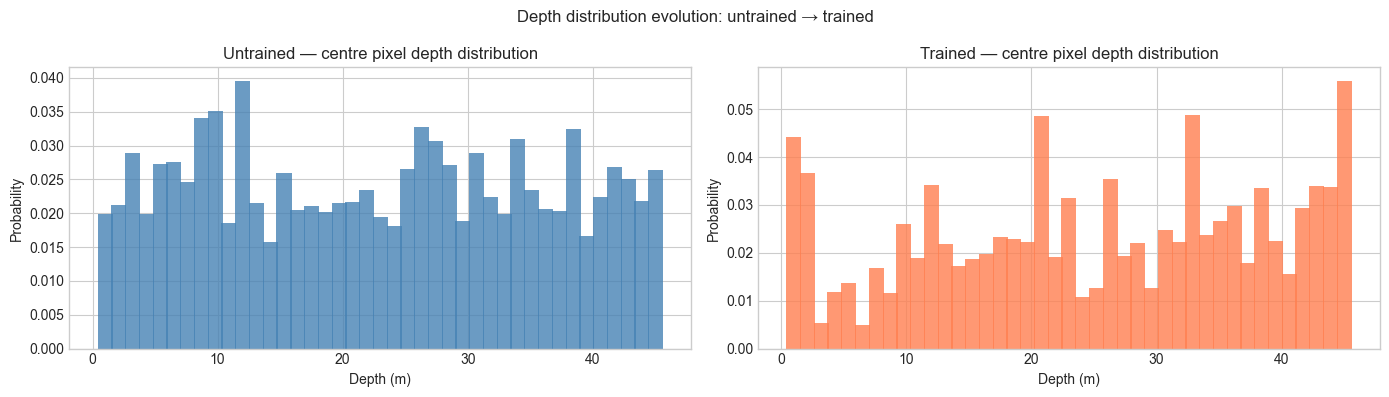

In [8]:
from models.lss.depth_bins import get_depth_bins

bins_np = get_depth_bins().numpy()
imgs_d  = batch['image'].to(device)

with torch.no_grad():
    _, depth_untrained = model_fresh(imgs_d, K, T)

H_, W_ = depth_untrained.shape[-2], depth_untrained.shape[-1]
row, col = H_//2, W_//2   # centre pixel

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

d_un = depth_untrained[0, :, row, col].cpu().numpy()
axes[0].bar(bins_np, d_un, width=1.2, color='steelblue', alpha=0.8)
axes[0].set_title('Untrained — centre pixel depth distribution')
axes[0].set_xlabel('Depth (m)'); axes[0].set_ylabel('Probability')

if lss_path().exists():
    with torch.no_grad():
        _, depth_trained = model_trained(imgs_d, K, T)
    d_tr = depth_trained[0, :, row, col].cpu().numpy()
    axes[1].bar(bins_np, d_tr, width=1.2, color='coral', alpha=0.8)
    axes[1].set_title('Trained — centre pixel depth distribution')
    axes[1].set_xlabel('Depth (m)'); axes[1].set_ylabel('Probability')
    print(f'Untrained peak depth: {bins_np[d_un.argmax()]:.1f}m')
    print(f'Trained   peak depth: {bins_np[d_tr.argmax()]:.1f}m')
else:
    axes[1].text(0.5, 0.5, 'Train first\nbash scripts/run_training_lss.sh',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Trained (not available yet)')

plt.suptitle('Depth distribution evolution: untrained → trained')
plt.tight_layout(); plt.show()

## 6. BEV prediction visualisation (trained model)

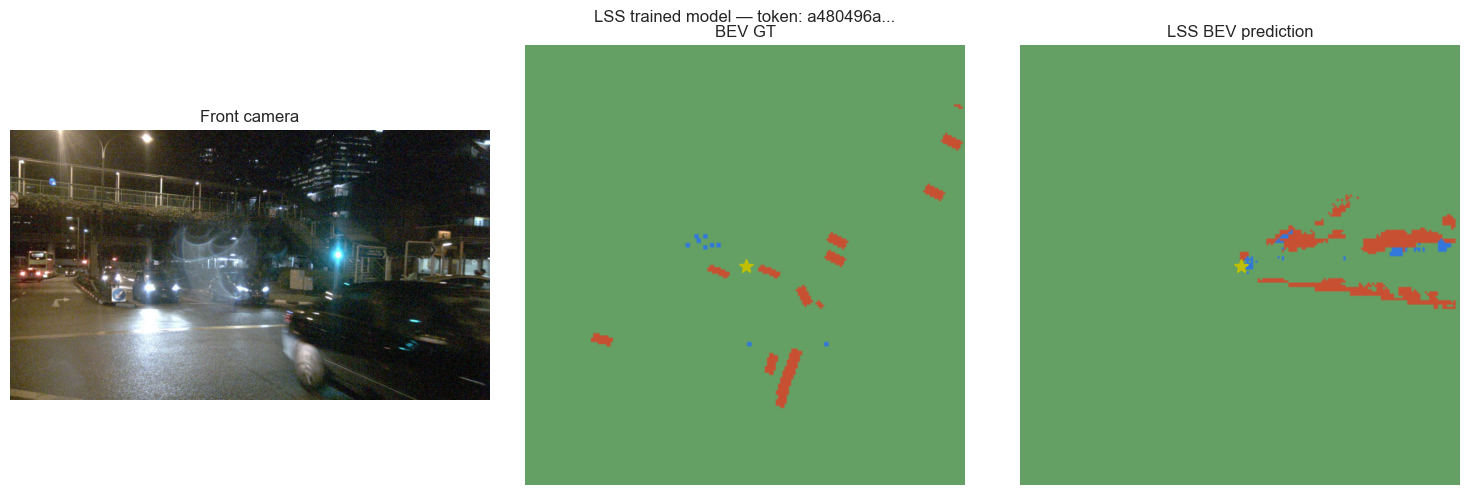

In [11]:
import cv2
from viz.colorize import colorize_bev
from data.nuscenes_loader import get_camera_data

if not lss_path().exists():
    print('Run training first, then re-run this cell.')
else:
    token    = batch['sample_token'][0]
    cam_data = get_camera_data(token)
    bgr      = cv2.imread(str(cam_data['image_path']))
    rgb      = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    with torch.no_grad():
        logits, _ = model_trained(imgs_d, K, T)

    sig = logits.sigmoid().cpu().numpy()[0]
    pred_binary = np.zeros_like(sig)
    pred_binary[0] = sig[0] > 0.45   # road
    pred_binary[1] = sig[1] > 0.15   # vehicle — much lower threshold
    pred_binary[2] = sig[2] > 0.10   # pedestrian — very low threshold
    gt_np       = batch['bev_gt'].numpy()[0]                          # (C,H,W)

    # combine channels → label map (last class wins where overlap)
    def to_label(channels):
        lbl = np.zeros((channels.shape[1], channels.shape[2]), dtype=np.uint8)
        for c in range(channels.shape[0]):
            lbl[channels[c] > 0.5] = c
        return lbl

    pred_lbl = to_label(pred_binary)
    gt_lbl   = to_label(gt_np)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb)
    axes[0].set_title('Front camera'); axes[0].axis('off')

    axes[1].imshow(colorize_bev(gt_lbl), origin='upper')
    axes[1].plot(100, 100, 'y*', markersize=10)
    axes[1].set_title('BEV GT'); axes[1].axis('off')

    axes[2].imshow(colorize_bev(pred_lbl), origin='upper')
    axes[2].plot(100, 100, 'y*', markersize=10)
    axes[2].set_title('LSS BEV prediction'); axes[2].axis('off')

    plt.suptitle(f'LSS trained model — token: {token[:8]}...')
    plt.tight_layout(); plt.show()

## Summary

Start training:
```bash
conda activate bev
bash scripts/run_training_lss.sh
```

Monitor:
```bash
tensorboard --logdir runs/lss_nuscenes
```

Expected after 50 epochs on nuScenes mini:
- drivable_area IoU: 0.30–0.55
- vehicle IoU: 0.15–0.35
- pedestrian IoU: 0.05–0.15
- mIoU: 0.15–0.35